In [50]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
class BollingerBandBacktester:
    def __init__(self, symbol, MA, start, end, std_dev=2, exit_threshold=0.03):
        self.symbol = symbol
        self.MA = MA
        self.start = start
        self.end = end
        self.std_dev = std_dev
        self.exit_threshold = exit_threshold
        self.results = None
        self.get_data()
        
    def get_data(self):
        df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
        data = df
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        data["MA"] = data.Close.rolling(self.MA).mean()
        data["std"] = data.Close.rolling(self.MA).std()
        data["upper_band"] = data["MA"] + self.std_dev * data["std"]
        data["lower_band"] = data["MA"] - self.std_dev * data["std"]
        data["upper_exit"] = data["upper_band"] * (1 + self.exit_threshold)
        data["lower_exit"] = data["lower_band"] * (1 - self.exit_threshold)
        data.dropna(inplace=True)
        self.data2 = data
        return data
    
    def test_results(self):
        data = self.data2.copy().dropna()
        data["position"] = 0  # Initialize positions
        position = 0  # Track current position (0: neutral, 1: long, -1: short)
        
        for i in range(1, len(data)):
            price = data["Close"].iloc[i].item()  # Extract scalar value
            upper_band = data["upper_band"].iloc[i].item()
            lower_band = data["lower_band"].iloc[i].item()
            upper_exit = data["upper_exit"].iloc[i].item()
            lower_exit = data["lower_exit"].iloc[i].item()
            
            # Buy (go long) when price touches or falls below lower band
            if price <= lower_band and position == 0:
                position = 1
            # Sell (go short) when price touches or exceeds upper band
            elif price >= upper_band and position == 0:
                position = -1
            # Exit long position if price exceeds upper exit threshold
            elif position == 1 and price >= upper_exit:
                position = 0
            # Exit short position if price falls below lower exit threshold
            elif position == -1 and price <= lower_exit:
                position = 0
                
            data.iloc[i, data.columns.get_loc("position")] = position
        
        data["strategy"] = data["returns"] * data["position"].shift(1)
        data.dropna(inplace=True)
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)
        perf = data["returnsstrategy"].iloc[-1]
        outperf = perf - data["returnsbh"].iloc[-1]
        self.results = data
        ret = np.exp(data["strategy"].sum())
        std = data["strategy"].std() * np.sqrt(252)
        return round(perf, 6), round(outperf, 6)
    
    def plot_results(self):
        if self.results is None:
            print("Run the test please")
        else:
            title = f"{self.symbol} | MA={self.MA} Bollinger Band Strategy"
            plt.style.use("seaborn-v0_8")
            self.results[["returnsbh", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
            plt.legend(["Buy & Hold", "Bollinger Band Strategy"], loc="upper left", fontsize=12)
            plt.xlabel("Date", fontsize=12)
            plt.ylabel("Cumulative Returns", fontsize=12)
            plt.show()
    
    def plot_bollinger_bands(self):
        data = self.data2.copy()
        plt.style.use("seaborn-v0_8")
        plt.figure(figsize=(12, 8))
        plt.plot(data["Close"], label="Close Price", color="blue")
        plt.plot(data["MA"], label=f"MA{self.MA}", color="orange")
        plt.plot(data["upper_band"], label="Upper Band", color="green", linestyle="--")
        plt.plot(data["lower_band"], label="Lower Band", color="red", linestyle="--")
        plt.plot(data["upper_exit"], label="Upper Exit", color="purple", linestyle=":")
        plt.plot(data["lower_exit"], label="Lower Exit", color="brown", linestyle=":")
        plt.legend(loc="upper left", fontsize=12)
        plt.title(f"{self.symbol} Price with Bollinger Bands (MA{self.MA})", fontsize=15)
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Price", fontsize=12)
        plt.show()
    
    def plot_bollinger_with_position(self, year=None):
        if self.results is None:
            print("Run the test please")
        else:
            data = self.results.copy()
            plt.style.use("seaborn-v0_8")
            if year:
                data = data.loc[str(year)]
            fig, ax1 = plt.subplots(figsize=(12, 8))
            ax1.plot(data.index, data["Close"], label="Close Price", color="blue")
            ax1.plot(data.index, data["MA"], label=f"MA{self.MA}", color="orange")
            ax1.plot(data.index, data["upper_band"], label="Upper Band", color="green", linestyle="--")
            ax1.plot(data.index, data["lower_band"], label="Lower Band", color="red", linestyle="--")
            ax1.set_xlabel("Date", fontsize=12)
            ax1.set_ylabel("Price", fontsize=12, color="blue")
            ax1.tick_params(axis="y", labelcolor="blue")
            ax1.legend(loc="upper left", fontsize=12)
            ax2 = ax1.twinx()
            ax2.plot(data.index, data["position"], label="Position", color="black", linestyle="-")
            ax2.set_ylabel("Position", fontsize=12, color="black")
            ax2.tick_params(axis="y", labelcolor="black")
            ax2.legend(loc="upper right", fontsize=12)
            plt.title(f"{self.symbol} - Bollinger Bands (MA{self.MA}) with Position", fontsize=15)
            plt.show()

In [55]:
tester=BollingerBandBacktester("NVDA",20,"2024-06-23","2025-06-23")

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_26130/3370605125.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
[*********************100%***********************]  1 of 1 completed


In [56]:
tester.test_results()

(1.259479, 0.094711)

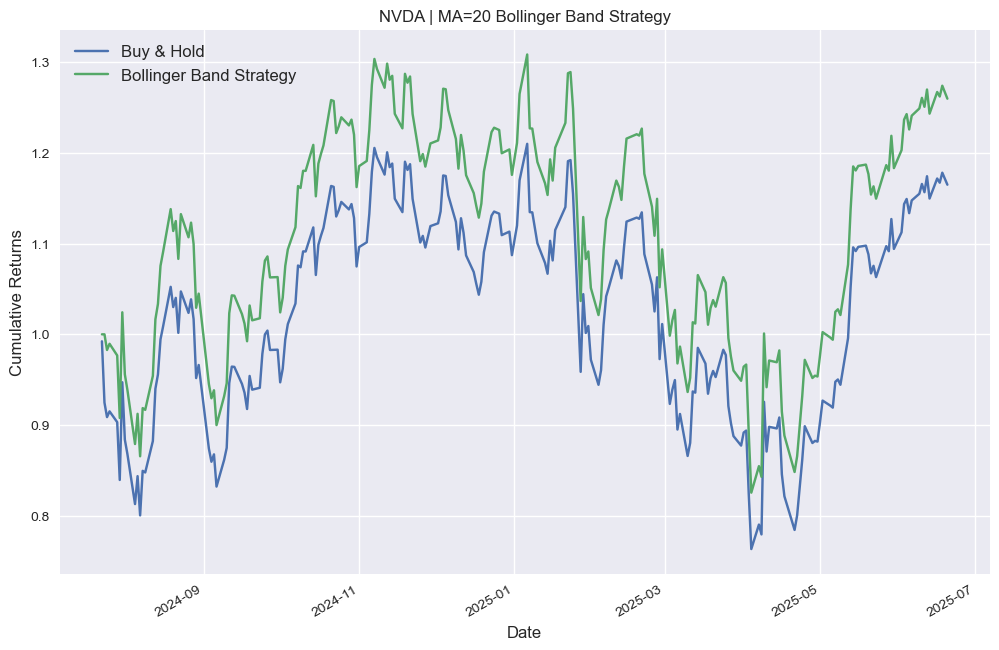

In [57]:
tester.plot_results()

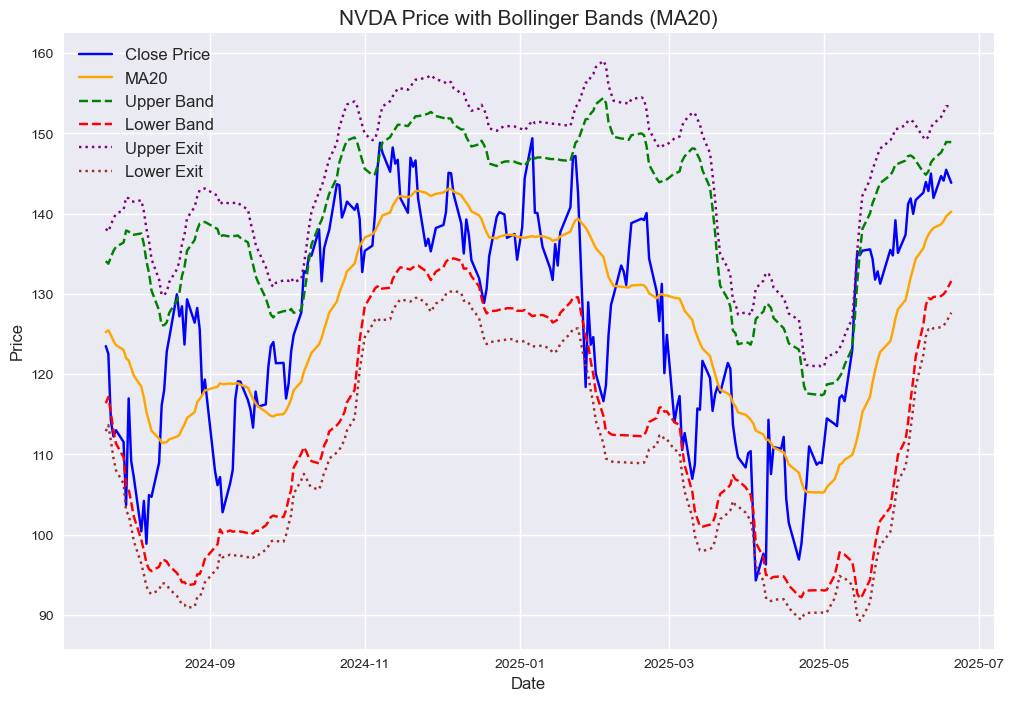

In [58]:
tester.plot_bollinger_bands()

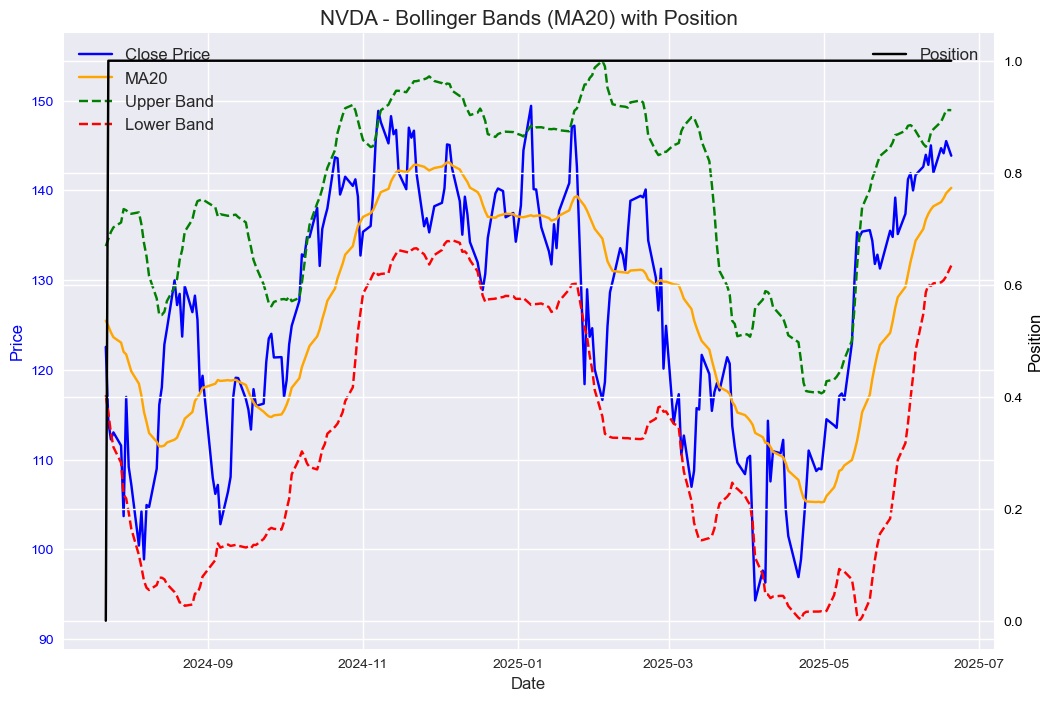

In [59]:
tester.plot_bollinger_with_position()